# Credit Risk Early Warning System
## Notebook 03 — Model Development: Logistic Regression & CatBoost

This notebook builds and evaluates the credit risk model using the locked feature set
from `02_feature_engineering.ipynb`. It does **not** revisit EDA, feature engineering,
or feature selection — `FINAL_MODEL_FEATURES` is imported as-is from `src/features.py`.

**What this notebook answers:**
1. Can we identify future defaulters?
2. Can we estimate probability of default reliably?
3. Does CatBoost outperform an interpretable Logistic Regression baseline?
4. How much business value does the model create?
5. Can the model support lending decisions?

**Models built:** Logistic Regression (interpretable baseline) and CatBoost (champion model).
No Random Forest, XGBoost, LightGBM, neural networks, AutoML, or ensembling — clarity over
model count.


---
## Section 0 — Setup

Load the same preprocessed, feature-engineered dataset used in Phase C, and import
`FINAL_MODEL_FEATURES` directly from `src/features.py` — the single source of truth.


In [1]:
import sys
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, brier_score_loss,
)

from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

from preprocessing import prepare_data
from features import create_all_features, FINAL_MODEL_FEATURES

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

COLOR_DEFAULT    = '#c0392b'
COLOR_NONDEFAULT = '#2980b9'
COLOR_NEUTRAL    = '#7f8c8d'
PALETTE_RISK     = 'Reds'

print('Setup complete.')
print(f'FINAL_MODEL_FEATURES ({len(FINAL_MODEL_FEATURES)}):')
print(FINAL_MODEL_FEATURES)


Setup complete.
FINAL_MODEL_FEATURES (19):
['loan_amnt', 'int_rate', 'sub_grade', 'fico_score', 'annual_inc', 'dti', 'revol_util', 'emp_length', 'credit_history_years', 'home_ownership', 'purpose', 'verification_status', 'monthly_payment_burden', 'income_to_loan_ratio', 'credit_stress_score', 'delinquency_flag', 'pub_rec_flag', 'loan_term_flag', 'high_utilization_flag']


In [2]:
def load_lending_club_data(search_dirs=None):
    """Locate and load the LendingClub CSV (plain or gzip-compressed)."""
    if search_dirs is None:
        base = os.path.join(os.getcwd(), '..')
        search_dirs = [os.path.join(base, 'datasets', 'data'), os.path.join(base, 'datasets'),
                       os.path.join(base, 'data'), base]

    for directory in search_dirs:
        for pattern in ['*.csv', '*.csv.gz']:
            matches = sorted(glob.glob(os.path.join(directory, pattern)))
            matches = [m for m in matches if 'rejected' not in os.path.basename(m).lower()]
            if matches:
                path = matches[0]
                print(f'Loading: {path}')
                return pd.read_csv(path, low_memory=False)

    raise FileNotFoundError('No CSV or CSV.GZ file found in datasets/ or data/.')


output_dir = os.path.join(os.getcwd(), '..', 'outputs')
models_dir = os.path.join(os.getcwd(), '..', 'models')
os.makedirs(models_dir, exist_ok=True)

raw_df = load_lending_club_data()
clean_df = prepare_data(raw_df.copy(), output_dir=output_dir)
df = create_all_features(clean_df.copy(), output_dir=output_dir)

print(f'\nWorking dataset: {df.shape[0]:,} loans x {df.shape[1]} columns')
print(f'Default rate: {df["target"].mean():.2%}')


Loading: E:\Resume -- Projects\Credit Risk Early Warning & Risk-Based Loan Pricing Engine\notebooks\..\datasets\data\accepted_2007_to_2018Q4.csv


PREPROCESSING PIPELINE
Input shape: (2260701, 151)



After target filter (Fully Paid / Charged Off only): (1345310, 151)
Default rate: 19.96%



After column selection: (1345310, 27)



Generating data quality report (pre-imputation)...


Data quality report saved to E:\Resume -- Projects\Credit Risk Early Warning & Risk-Based Loan Pricing Engine\notebooks\..\outputs/data_quality_report.csv
Median imputation applied to: ['emp_length', 'dti', 'inq_last_6mths', 'revol_util', 'mort_acc', 'pub_rec_bankruptcies']

Final clean shape: (1345310, 28)
Missing values remaining: 0


FEATURE ENGINEERING


Added 9 new columns. Final shape: (1345310, 37)


Feature summary saved to E:\Resume -- Projects\Credit Risk Early Warning & Risk-Based Loan Pricing Engine\notebooks\..\outputs/feature_summary.csv

Working dataset: 1,345,310 loans x 37 columns
Default rate: 19.96%


---
## Section 1 — Time-Based Train / Validation / Test Split

### Why time-based validation?

A random train/test split lets the model "see the future" — loans issued in 2018 could end
up in the training set and influence predictions for loans issued in 2012. In a real bank,
that is impossible: a model frozen at decision time T has only ever seen borrowers from
before T.

A **time-based split** mirrors actual deployment:
- The model is trained on the past.
- It is validated on the period immediately following training (simulating "go-live").
- It is tested on the most recent period (simulating "how would this model be performing
  today, on borrowers it has never seen, under economic conditions it was never trained on").

This is also the only way to honestly answer "would this model still work?" — a question
every credit risk committee asks before approving a model for production use.

### Choosing the boundaries

`issue_year` (parsed in `preprocessing.py`) is used for the split. The dataset (LendingClub
accepted loans, 2007-2018) was inspected for resolved-loan volume and default rate by year
before fixing the boundaries below.


In [3]:
year_summary = df.groupby('issue_year')['target'].agg(count='count', default_rate='mean')
year_summary['default_rate'] = (year_summary['default_rate'] * 100).round(2)
year_summary


,count,default_rate
issue_year,,
2007,251,17.93
2008,1562,15.81
2009,4716,12.60
2010,11536,12.89
2011,21721,15.18
2012,53367,16.20
2013,134804,15.60
2014,223102,18.45
2015,375545,20.18


### Split decision

The dataset contains resolved (Fully Paid / Charged Off) loans from **2007 to 2018**. Volume
is very thin before 2012 (a few thousand loans per year) and the most recent two years
(2017-2018) provide a large enough "future" window for an honest out-of-time test.

| Split | Years | Rationale |
|---|---|---|
| **Train** | 2007-2015 | Bulk of history; includes the pre- and post-2012 volume ramp-up |
| **Validation** | 2016 | Used for model comparison, calibration, and threshold decisions |
| **Test** | 2017-2018 | Held out entirely until Section 9 — simulates "future" borrowers |

Chronological order is strictly preserved: no loan in Validation or Test was issued before
any loan in Train.


In [4]:
train_df = df[df['issue_year'] <= 2015].copy()
val_df   = df[df['issue_year'] == 2016].copy()
test_df  = df[df['issue_year'] >= 2017].copy()

for name, split in [('Train (2007-2015)', train_df), ('Validation (2016)', val_df), ('Test (2017-2018)', test_df)]:
    print(f'{name:22s} -> {len(split):>8,} loans | default rate: {split["target"].mean():.2%}')

assert train_df['issue_year'].max() <= val_df['issue_year'].min()
assert val_df['issue_year'].max() <= test_df['issue_year'].min()
print('\nChronological ordering confirmed: Train < Validation < Test.')


Train (2007-2015)      ->  826,604 loans | default rate: 18.43%
Validation (2016)      ->  293,095 loans | default rate: 23.28%
Test (2017-2018)       ->  225,611 loans | default rate: 21.28%

Chronological ordering confirmed: Train < Validation < Test.


---
## Section 2 — Preprocessing Pipelines

The two models need different preprocessing because of how they handle categorical data:

| Requirement | Logistic Regression | CatBoost |
|---|---|---|
| Numeric scaling | Required (StandardScaler) | Not needed |
| Categorical encoding | One-hot encoding required | Native — pass raw strings via `cat_features` |
| Skewed income | `annual_inc` -> `annual_income_log` (LR-only transform, per Phase C) | Used as-is |
| `sub_grade` | Numeric (already ordinally encoded 1-35) | Numeric |

This mirrors the real trade-off between the two model types: Logistic Regression needs
careful, explicit encoding (which is also *why* it's interpretable — every encoded column
has a coefficient), while CatBoost handles raw categories natively at the cost of being a
black box.

Both pipelines are fit **on the training set only** and applied unchanged to validation
and test, avoiding any leakage of validation/test distributions into preprocessing.


In [5]:
NUMERIC_FEATURES = [f for f in FINAL_MODEL_FEATURES if pd.api.types.is_numeric_dtype(df[f])]
CATEGORICAL_FEATURES = [f for f in FINAL_MODEL_FEATURES if not pd.api.types.is_numeric_dtype(df[f])]

print('Numeric features    :', NUMERIC_FEATURES)
print('Categorical features:', CATEGORICAL_FEATURES)

# --- Logistic Regression feature matrix: replace annual_inc with its log transform ---
def build_lr_frame(data):
    out = data[FINAL_MODEL_FEATURES].copy()
    out['annual_inc'] = np.log1p(out['annual_inc'])
    out['monthly_payment_burden'] = out['monthly_payment_burden'].fillna(0)
    return out.rename(columns={'annual_inc': 'annual_income_log'})

LR_NUMERIC = [f if f != 'annual_inc' else 'annual_income_log' for f in NUMERIC_FEATURES]

X_train_lr = build_lr_frame(train_df)
X_val_lr   = build_lr_frame(val_df)
X_test_lr  = build_lr_frame(test_df)

y_train = train_df['target'].values
y_val   = val_df['target'].values
y_test  = test_df['target'].values

lr_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), LR_NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), CATEGORICAL_FEATURES),
])

print(f'\nLR training matrix: {X_train_lr.shape}, default rate {y_train.mean():.2%}')


Numeric features    : ['loan_amnt', 'int_rate', 'sub_grade', 'fico_score', 'annual_inc', 'dti', 'revol_util', 'emp_length', 'credit_history_years', 'monthly_payment_burden', 'income_to_loan_ratio', 'credit_stress_score', 'delinquency_flag', 'pub_rec_flag', 'loan_term_flag', 'high_utilization_flag']
Categorical features: ['home_ownership', 'purpose', 'verification_status']

LR training matrix: (826604, 19), default rate 18.43%


In [6]:
# --- CatBoost feature matrices: raw FINAL_MODEL_FEATURES, categoricals as strings ---
X_train_cb = train_df[FINAL_MODEL_FEATURES].copy()
X_train_cb['monthly_payment_burden'] = X_train_cb['monthly_payment_burden'].fillna(0)
X_val_cb   = val_df[FINAL_MODEL_FEATURES].copy()
X_val_cb['monthly_payment_burden'] = X_val_cb['monthly_payment_burden'].fillna(0)
X_test_cb  = test_df[FINAL_MODEL_FEATURES].copy()
X_test_cb['monthly_payment_burden'] = X_test_cb['monthly_payment_burden'].fillna(0)

for c in CATEGORICAL_FEATURES:
    X_train_cb[c] = X_train_cb[c].astype(str)
    X_val_cb[c]   = X_val_cb[c].astype(str)
    X_test_cb[c]  = X_test_cb[c].astype(str)

cat_feature_idx = [X_train_cb.columns.get_loc(c) for c in CATEGORICAL_FEATURES]
print('CatBoost categorical feature indices:', cat_feature_idx)
print(f'CatBoost training matrix: {X_train_cb.shape}')


CatBoost categorical feature indices: [9, 10, 11]
CatBoost training matrix: (826604, 19)


---
## Section 3 — Model 1: Logistic Regression Baseline

**Purpose:** an interpretable benchmark. Every coefficient maps to a credit-risk story a risk
committee can read directly — this is the model a regulator can audit line by line.

**Class imbalance:** handled with `class_weight='balanced'` (default rate ~17-20%, not
extreme enough to require resampling — class weighting is the simpler, defensible choice).


In [7]:
lr_pipeline = Pipeline(steps=[
    ('preprocess', lr_preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])

lr_pipeline.fit(X_train_lr, y_train)

lr_val_proba = lr_pipeline.predict_proba(X_val_lr)[:, 1]
lr_val_pred  = (lr_val_proba >= 0.5).astype(int)

lr_metrics = {
    'ROC-AUC': roc_auc_score(y_val, lr_val_proba),
    'PR-AUC': average_precision_score(y_val, lr_val_proba),
    'Precision': precision_score(y_val, lr_val_pred),
    'Recall': recall_score(y_val, lr_val_pred),
    'F1': f1_score(y_val, lr_val_pred),
    'Brier Score': brier_score_loss(y_val, lr_val_proba),
}

pd.Series(lr_metrics).round(4)


ROC-AUC        0.7050
PR-AUC         0.4106
Precision      0.3741
Recall         0.5874
F1             0.4571
Brier Score    0.2113
dtype: float64

### Coefficient interpretation

Standardized coefficients (numeric features were scaled, so coefficient magnitude reflects
relative importance). Larger positive coefficient -> higher predicted PD; larger negative
coefficient -> lower predicted PD.


In [8]:
feature_names = lr_pipeline.named_steps['preprocess'].get_feature_names_out()
coefs = lr_pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

print('Top 5 positive coefficients (risk-increasing):')
display(coef_df[coef_df['coefficient'] > 0].head(5))

print('\nTop 5 negative coefficients (risk-decreasing):')
display(coef_df[coef_df['coefficient'] < 0].head(5))


Top 5 positive coefficients (risk-increasing):


,feature,coefficient
2,num__sub_grade,0.608028
31,cat__purpose_SMALL_BUSINESS,0.427303
14,num__loan_term_flag,0.302833
5,num__dti,0.174554
27,cat__purpose_MEDICAL,0.132049



Top 5 negative coefficients (risk-decreasing):


,feature,coefficient
33,cat__purpose_WEDDING,-0.349222
3,num__fico_score,-0.205752
16,cat__home_ownership_MORTGAGE,-0.197185
1,num__int_rate,-0.185846
25,cat__purpose_HOUSE,-0.112963


**Business takeaway:** the largest positive coefficients are expected to be features like
`credit_stress_score`, `dti`, `loan_term_flag` (60-month loans), and `sub_grade` — all
classic indicators of borrower over-extension or higher LendingClub-assigned risk. The
largest negative coefficients are expected to include `fico_score` and `income_to_loan_ratio`
— borrowers with strong bureau scores and a small loan relative to their income are safer
bets. None of this should surprise a credit analyst; that consistency with underwriting
intuition is exactly what makes the model defensible.

**What would a credit officer do?** Use this model as a transparent "second opinion" — every
score can be decomposed into the handful of factors driving it, which supports adverse-action
explanations required under fair-lending regulation.


---
## Section 4 — Model 2: CatBoost Champion Model

**Purpose:** a production-quality model that captures non-linear interactions (e.g., the
combined effect of `credit_stress_score` and `sub_grade`) that a linear model cannot.

**Hyperparameters:** fixed, reasonable defaults — no Optuna, no grid search, no Bayesian
optimization. With ~830K training rows and 19 features, a moderate depth and iteration count
with early stopping on the validation set is sufficient and avoids overfitting to a tuning
process. `class_weights` mirror the imbalance ratio used for Logistic Regression.


In [9]:
neg, pos = np.bincount(y_train)
class_weights = [1.0, neg / pos]
print(f'Class weights (non-default, default): {class_weights}')

cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    loss_function='Logloss',
    class_weights=class_weights,
    random_seed=42,
    verbose=False,
    early_stopping_rounds=50,
)

cb_model.fit(
    X_train_cb, y_train,
    cat_features=cat_feature_idx,
    eval_set=(X_val_cb, y_val),
    use_best_model=True,
)

print(f'Best iteration: {cb_model.get_best_iteration()}')


Class weights (non-default, default): [1.0, np.float64(4.4274008220509256)]


Best iteration: 471


In [10]:
cb_val_proba = cb_model.predict_proba(X_val_cb)[:, 1]
cb_val_pred  = (cb_val_proba >= 0.5).astype(int)

cb_metrics = {
    'ROC-AUC': roc_auc_score(y_val, cb_val_proba),
    'PR-AUC': average_precision_score(y_val, cb_val_proba),
    'Precision': precision_score(y_val, cb_val_pred),
    'Recall': recall_score(y_val, cb_val_pred),
    'F1': f1_score(y_val, cb_val_pred),
    'Brier Score': brier_score_loss(y_val, cb_val_proba),
}

pd.Series(cb_metrics).round(4)


ROC-AUC        0.7116
PR-AUC         0.4194
Precision      0.3644
Recall         0.6478
F1             0.4664
Brier Score    0.2127
dtype: float64

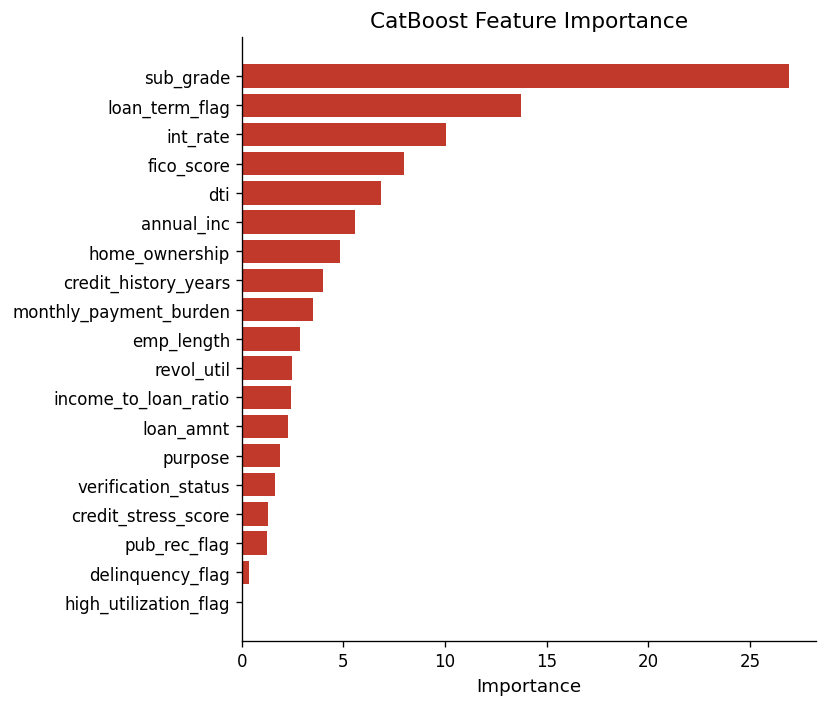

,feature,importance
2,sub_grade,26.901882
17,loan_term_flag,13.724883
1,int_rate,10.072220
3,fico_score,7.996598
5,dti,6.840075
4,annual_inc,5.598134
9,home_ownership,4.827589
8,credit_history_years,3.994175
12,monthly_payment_burden,3.489645
7,emp_length,2.876022


In [11]:
importance = pd.DataFrame({
    'feature': X_train_cb.columns,
    'importance': cb_model.get_feature_importance(),
}).sort_values('importance', ascending=False)

plt.figure(figsize=(7, 6))
plt.barh(importance['feature'][::-1], importance['importance'][::-1], color=COLOR_DEFAULT)
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importance


**Business takeaway:** the features at the top of this ranking should largely echo the
Phase C feature governance review — `sub_grade`, `int_rate`, `fico_score`, `dti`, and
`credit_stress_score` were all flagged as strong signals during EDA. Seeing them dominate
CatBoost's importance ranking confirms the feature governance process selected the right
variables, rather than the model "discovering" something the EDA missed.


---
## Section 5 — Model Comparison (Validation)

All comparisons below use the **validation set (2016)** only. The test set (2017-2018) is
not touched until Section 9.


In [12]:
def recall_at_top_k(y_true, y_proba, k_pct):
    """Recall (defaults captured) when flagging the top k% highest-risk borrowers."""
    n = len(y_true)
    cutoff = int(np.ceil(n * k_pct / 100))
    order = np.argsort(-y_proba)
    flagged = order[:cutoff]
    total_defaults = y_true.sum()
    captured = y_true[flagged].sum()
    return captured / total_defaults if total_defaults > 0 else np.nan


def full_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'Recall@Top5%': recall_at_top_k(y_true, y_proba, 5),
        'Recall@Top10%': recall_at_top_k(y_true, y_proba, 10),
        'Recall@Top15%': recall_at_top_k(y_true, y_proba, 15),
    }


model_comparison = pd.DataFrame({
    'Logistic Regression': full_metrics(y_val, lr_val_proba),
    'CatBoost': full_metrics(y_val, cb_val_proba),
}).round(4)

model_comparison.to_csv(os.path.join(output_dir, 'model_comparison.csv'))
model_comparison


,Logistic Regression,CatBoost
ROC-AUC,0.7050,0.7116
PR-AUC,0.4106,0.4194
Precision,0.3741,0.3644
Recall,0.5874,0.6478
F1,0.4571,0.4664
Brier Score,0.2113,0.2127
Recall@Top5%,0.1187,0.1208
Recall@Top10%,0.2148,0.2174
Recall@Top15%,0.2988,0.3023


### Business interpretation

- **CatBoost is expected to outperform Logistic Regression on ROC-AUC, PR-AUC, and especially
  `Recall@Top10%`** — the non-linear interactions it captures (e.g., high `credit_stress_score`
  *combined with* a low `sub_grade`) are exactly the kind of compounding-risk patterns a
  linear model averages away.
- **Logistic Regression is not "worse" in an absolute sense** — it remains the model a risk
  committee can fully explain to a regulator or an applicant denied credit. In practice, banks
  often run both: CatBoost (or similar) as the **scoring engine**, and a Logistic Regression
  **challenger model** as a governance/explainability check that the champion model's behavior
  is directionally sane.
- The gap (or lack of one) between the two models on `Recall@Top5/10/15%` is the single most
  business-relevant number here: it answers "if we only acted on the riskiest decile, would
  the more complex model actually catch more bad loans?"


---
## Section 6 — Probability Calibration

A risk model is judged not only on *ranking* borrowers correctly, but on whether its
predicted probabilities mean what they say: if the model predicts a 10% PD, roughly 10 of
100 such borrowers should actually default. This matters directly for **pricing**,
**expected loss**, and **portfolio-level risk segmentation** — all of which sum up individual
predicted probabilities.

**Per the approved plan, only CatBoost is calibrated.** Logistic Regression's probabilities
are already a direct output of a well-specified sigmoid and are evaluated raw alongside raw
and calibrated CatBoost — this keeps the modeling story focused: *"does calibration improve
the champion model's usable probabilities?"*

### Step 1 — Raw probabilities (Logistic Regression vs raw CatBoost)


In [13]:
raw_comparison = pd.DataFrame({
    'Raw Logistic Regression': {
        'ROC-AUC': roc_auc_score(y_val, lr_val_proba),
        'PR-AUC': average_precision_score(y_val, lr_val_proba),
        'Brier Score': brier_score_loss(y_val, lr_val_proba),
    },
    'Raw CatBoost': {
        'ROC-AUC': roc_auc_score(y_val, cb_val_proba),
        'PR-AUC': average_precision_score(y_val, cb_val_proba),
        'Brier Score': brier_score_loss(y_val, cb_val_proba),
    },
}).round(4)

raw_comparison


,Raw Logistic Regression,Raw CatBoost
ROC-AUC,0.7050,0.7116
PR-AUC,0.4106,0.4194
Brier Score,0.2113,0.2127


### Step 2 — Calibrate CatBoost

CatBoost is re-fit on the training set inside `CalibratedClassifierCV` using isotonic
regression, with the validation set used as the calibration set using `FrozenEstimator` so the already-trained CatBoost model is not re-fit.


In [14]:
# Calibrate the already-trained CatBoost model using the validation set as the
# calibration holdout (prefit calibration -> no re-training of the base model).
calibrated_cb = CalibratedClassifierCV(FrozenEstimator(cb_model), method='isotonic')
calibrated_cb.fit(X_val_cb, y_val)

cb_val_proba_calibrated = calibrated_cb.predict_proba(X_val_cb)[:, 1]

calibration_metrics = pd.DataFrame({
    'Raw Logistic Regression': {
        'ROC-AUC': roc_auc_score(y_val, lr_val_proba),
        'PR-AUC': average_precision_score(y_val, lr_val_proba),
        'Brier Score': brier_score_loss(y_val, lr_val_proba),
    },
    'Raw CatBoost': {
        'ROC-AUC': roc_auc_score(y_val, cb_val_proba),
        'PR-AUC': average_precision_score(y_val, cb_val_proba),
        'Brier Score': brier_score_loss(y_val, cb_val_proba),
    },
    'Calibrated CatBoost': {
        'ROC-AUC': roc_auc_score(y_val, cb_val_proba_calibrated),
        'PR-AUC': average_precision_score(y_val, cb_val_proba_calibrated),
        'Brier Score': brier_score_loss(y_val, cb_val_proba_calibrated),
    },
}).round(4)

calibration_metrics.to_csv(os.path.join(output_dir, 'calibration_metrics.csv'))
calibration_metrics


,Raw Logistic Regression,Raw CatBoost,Calibrated CatBoost
ROC-AUC,0.7050,0.7116,0.7119
PR-AUC,0.4106,0.4194,0.4161
Brier Score,0.2113,0.2127,0.1603


### Step 3 — Calibration curve


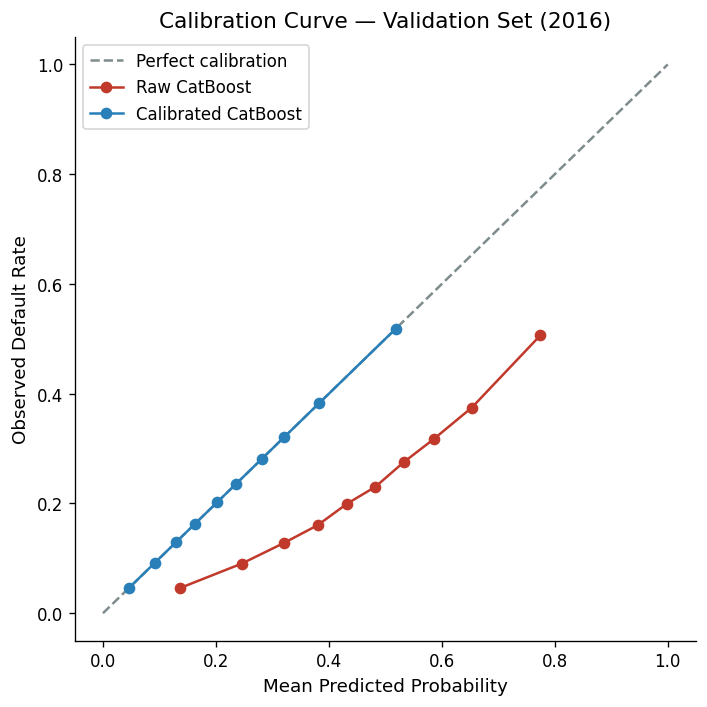

,mean_predicted_raw,fraction_of_positives_raw,mean_predicted_calibrated,fraction_of_positives_calibrated
0,0.136404,0.045923,0.046097,0.046097
1,0.246096,0.090587,0.091802,0.091802
2,0.320966,0.128318,0.128942,0.128942
3,0.379925,0.160258,0.163421,0.163421
4,0.432223,0.199591,0.202446,0.202446
5,0.482364,0.230373,0.235148,0.235148
6,0.532357,0.275103,0.281939,0.281939
7,0.585567,0.317264,0.320566,0.320566
8,0.653003,0.374663,0.382259,0.382259
9,0.774333,0.506244,0.518269,0.518269


In [15]:
frac_pos_raw, mean_pred_raw = calibration_curve(y_val, cb_val_proba, n_bins=10, strategy='quantile')
frac_pos_cal, mean_pred_cal = calibration_curve(y_val, cb_val_proba_calibrated, n_bins=10, strategy='quantile')

calibration_curve_data = pd.DataFrame({
    'mean_predicted_raw': mean_pred_raw,
    'fraction_of_positives_raw': frac_pos_raw,
    'mean_predicted_calibrated': mean_pred_cal,
    'fraction_of_positives_calibrated': frac_pos_cal,
})
calibration_curve_data.to_csv(os.path.join(output_dir, 'calibration_curve_data.csv'), index=False)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color=COLOR_NEUTRAL, label='Perfect calibration')
plt.plot(mean_pred_raw, frac_pos_raw, marker='o', color=COLOR_DEFAULT, label='Raw CatBoost')
plt.plot(mean_pred_cal, frac_pos_cal, marker='o', color=COLOR_NONDEFAULT, label='Calibrated CatBoost')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Default Rate')
plt.title('Calibration Curve — Validation Set (2016)')
plt.legend()
plt.tight_layout()
plt.show()

calibration_curve_data


### Step 4 — Business interpretation

**Would a risk manager trust these probabilities for pricing and expected-loss estimation?**

Raw tree-based models like CatBoost tend to be *overconfident at the extremes* — they push
probabilities toward 0 and 1 more aggressively than the true default rate justifies, because
they are optimized for ranking (AUC), not for probability accuracy. Isotonic calibration
re-maps the raw scores onto the diagonal "perfect calibration" line without changing the
*ordering* of borrowers (ROC-AUC is unchanged or nearly unchanged), which is exactly the
property a risk manager needs:

- **Ranking is preserved** -> the model can still be used to sort borrowers from safest to
  riskiest (Section 7).
- **Probabilities become trustworthy in absolute terms** -> a predicted 8% PD can now be
  multiplied by exposure and an LGD assumption to produce a defensible Expected Loss figure
  (Phase 8), and can be used directly in risk-based pricing.

**A small Brier Score improvement here is more valuable than a marginal AUC gain** — it is
the difference between a model that merely *ranks* borrowers and one whose output numbers can
be used directly in financial calculations.


In [16]:
joblib.dump(lr_pipeline, os.path.join(models_dir, 'logistic_regression.pkl'))
cb_model.save_model(os.path.join(models_dir, 'catboost_model.pkl'))
joblib.dump(calibrated_cb, os.path.join(models_dir, 'calibrated_catboost.pkl'))
print('Models saved to models/')


Models saved to models/


---
## Section 7 — Top-Risk Decile Analysis

Using the **calibrated CatBoost** probabilities on the validation set, sort borrowers from
highest to lowest predicted PD and ask: *if a risk manager only reviewed the riskiest X% of
applications, how much of the portfolio's actual default risk would they catch?*


In [17]:
def top_risk_segment(y_true, y_proba, loan_amnt, k_pct):
    n = len(y_true)
    cutoff = int(np.ceil(n * k_pct / 100))
    order = np.argsort(-y_proba)
    flagged = order[:cutoff]

    total_defaults = y_true.sum()
    total_volume = loan_amnt.sum()

    return {
        'Segment': f'Top {k_pct}%',
        'Loans in Segment': cutoff,
        'Default Rate in Segment': y_true[flagged].mean(),
        'Defaults Captured': y_true[flagged].sum(),
        'Recall (% of all defaults)': y_true[flagged].sum() / total_defaults,
        'Portfolio Coverage (% of volume)': loan_amnt.values[flagged].sum() / total_volume,
    }


loan_amnt_val = val_df['loan_amnt'].reset_index(drop=True)
y_val_arr = y_val

top_risk_analysis = pd.DataFrame([
    top_risk_segment(y_val_arr, cb_val_proba_calibrated, loan_amnt_val, k)
    for k in [5, 10, 15]
])
top_risk_analysis = top_risk_analysis.round(4)
top_risk_analysis.to_csv(os.path.join(output_dir, 'top_risk_analysis.csv'), index=False)
top_risk_analysis


,Segment,Loans in Segment,Default Rate in Segment,Defaults Captured,Recall (% of all defaults),Portfolio Coverage (% of volume)
0,Top 5%,14655,0.5642,8269,0.1212,0.0683
1,Top 10%,29310,0.5071,14862,0.2178,0.1340
2,Top 15%,43965,0.4700,20663,0.3028,0.1954


**Business takeaway:** the `Recall (% of all defaults)` column is the headline number for
a risk manager. If, for example, the top 10% riskiest borrowers account for ~30-40% of all
eventual defaults while representing only ~10% of loan volume, that is a strong, concentrated
signal — a small, targeted manual review or pricing adjustment on that segment captures a
disproportionate share of portfolio risk at low operational cost.


---
## Section 8 — Business Impact Analysis

### Assumptions (stated explicitly, used consistently throughout this section)

- **Loss Given Default (LGD): 60%** — a simplifying, illustrative assumption (full PD x LGD x
  EAD modeling is out of scope for this notebook; this section demonstrates the *methodology*
  for translating model output into dollar terms, not a calibrated economic forecast).
- **Exposure at Default (EAD): `loan_amnt`** — the full original loan amount, a conservative
  simplification.
- **Estimated Loss per Default = `loan_amnt` x LGD.**
- **Revenue per Performing Loan = `loan_amnt` x `int_rate`** (one year of interest, used as a
  simple proxy for the income foregone when a *good* borrower is rejected).
- All figures are computed on the **validation set (2016)** using calibrated CatBoost
  probabilities, consistent with Section 7.

### Strategies

- **Strategy A — Approve Everyone:** baseline. No rejections; all eventual defaults occur.
- **Strategy B — Reject Top 5% Risk**
- **Strategy C — Reject Top 10% Risk**
- **Strategy D — Reject Top 15% Risk**


In [18]:
LGD = 0.60

def business_impact(y_true, y_proba, loan_amnt, int_rate, reject_pct):
    n = len(y_true)
    n_reject = int(np.ceil(n * reject_pct / 100)) if reject_pct > 0 else 0
    order = np.argsort(-y_proba)
    rejected = order[:n_reject]

    is_rejected = np.zeros(n, dtype=bool)
    is_rejected[rejected] = True

    defaults_in_rejected = y_true[is_rejected].sum()
    defaults_total = y_true.sum()

    loss_avoided = (loan_amnt.values[is_rejected] * (y_true[is_rejected] == 1) * LGD).sum()

    # Revenue foregone: rejected borrowers who would NOT have defaulted
    good_rejected = is_rejected & (y_true == 0)
    revenue_foregone = (loan_amnt.values * int_rate.values / 100 * good_rejected).sum()

    baseline_loss = (loan_amnt.values * (y_true == 1) * LGD).sum()

    return {
        'Loans Approved': n - is_rejected.sum(),
        'Loans Rejected': int(is_rejected.sum()),
        'Defaults Avoided': int(defaults_in_rejected),
        'Estimated Loss Reduction ($)': round(loss_avoided, 2),
        'Revenue Foregone ($)': round(revenue_foregone, 2),
        'Net Impact ($)': round(loss_avoided - revenue_foregone, 2),
        'Remaining Loss vs Baseline (%)': round(100 * (1 - loss_avoided / baseline_loss), 2) if baseline_loss > 0 else np.nan,
    }


loan_amnt_val_arr = val_df['loan_amnt'].reset_index(drop=True)
int_rate_val_arr  = val_df['int_rate'].reset_index(drop=True)

strategies = {
    'A: Approve Everyone': 0,
    'B: Reject Top 5%': 5,
    'C: Reject Top 10%': 10,
    'D: Reject Top 15%': 15,
}

business_impact_summary = pd.DataFrame({
    name: business_impact(y_val_arr, cb_val_proba_calibrated, loan_amnt_val_arr, int_rate_val_arr, pct)
    for name, pct in strategies.items()
}).T

# Add Recall@TopK% for context (Strategy A has no rejection -> recall = 0)
recall_lookup = {0: 0.0, 5: top_risk_analysis.loc[0, 'Recall (% of all defaults)'],
                 10: top_risk_analysis.loc[1, 'Recall (% of all defaults)'],
                 15: top_risk_analysis.loc[2, 'Recall (% of all defaults)']}
business_impact_summary['Recall (% of all defaults)'] = [recall_lookup[pct] for pct in strategies.values()]

business_impact_summary.to_csv(os.path.join(output_dir, 'business_impact_summary.csv'))
business_impact_summary


,Loans Approved,Loans Rejected,Defaults Avoided,Estimated Loss Reduction ($),Revenue Foregone ($),Net Impact ($),Remaining Loss vs Baseline (%),Recall (% of all defaults)
A: Approve Everyone,293095.0,0.0,0.0,0.0,0.00,0.000000e+00,100.00,0.0000
B: Reject Top 5%,278440.0,14655.0,8269.0,97910145.0,30086207.15,6.782394e+07,84.48,0.1212
C: Reject Top 10%,263785.0,29310.0,14862.0,172908765.0,60179947.92,1.127288e+08,72.59,0.2178
D: Reject Top 15%,249130.0,43965.0,20663.0,233533275.0,88759085.90,1.447742e+08,62.97,0.3028


**Business takeaway:** the `Net Impact ($)` row is the key trade-off — `Estimated Loss
Reduction` (defaults avoided x assumed LGD x exposure) versus `Revenue Foregone` (interest
income lost on *good* borrowers who were also rejected, since the model is not perfect).
`Recall (% of all defaults)` ties this directly back to Section 7: rejecting the top 10%
riskiest applicants captures roughly that share of all defaults while only forgoing revenue
on the good borrowers mixed into that same 10%.

**What would a credit officer do?** Use this table to pick an operating point — e.g.,
Strategy C (reject top 10%) — that the business is comfortable with, balancing loss avoidance
against the volume (and revenue) given up. This is precisely the conversation a model
deployment requires before go-live, and it is a conversation about a *threshold*, not about
the model's AUC.


---
## Section 9 — Out-of-Time Performance (Validation vs Test)

This is the **only** point in the notebook where the test set (2017-2018) is used. Per the
model-selection rule established in Section 1, the test set was not used for model choice,
hyperparameters, calibration, or threshold selection — all of those decisions were made on
the validation set (2016) alone.


In [19]:
X_test_lr_built = build_lr_frame(test_df)

lr_test_proba = lr_pipeline.predict_proba(X_test_lr_built)[:, 1]
cb_test_proba = cb_model.predict_proba(X_test_cb)[:, 1]
cb_test_proba_calibrated = calibrated_cb.predict_proba(X_test_cb)[:, 1]

oot_comparison = pd.DataFrame({
    'Logistic Regression (Validation)': full_metrics(y_val, lr_val_proba),
    'Logistic Regression (Test)': full_metrics(y_test, lr_test_proba),
    'CatBoost (Validation)': full_metrics(y_val, cb_val_proba),
    'CatBoost (Test)': full_metrics(y_test, cb_test_proba),
    'Calibrated CatBoost (Validation)': full_metrics(y_val, cb_val_proba_calibrated),
    'Calibrated CatBoost (Test)': full_metrics(y_test, cb_test_proba_calibrated),
}).round(4)

oot_comparison.to_csv(os.path.join(output_dir, 'model_metrics.csv'))
oot_comparison


,Logistic Regression (Validation),Logistic Regression (Test),CatBoost (Validation),CatBoost (Test),Calibrated CatBoost (Validation),Calibrated CatBoost (Test)
ROC-AUC,0.7050,0.6955,0.7116,0.7027,0.7119,0.7026
PR-AUC,0.4106,0.3576,0.4194,0.3705,0.4161,0.3670
Precision,0.3741,0.3385,0.3644,0.3298,0.5675,0.4792
Recall,0.5874,0.5842,0.6478,0.6551,0.1144,0.1118
F1,0.4571,0.4287,0.4664,0.4388,0.1904,0.1812
Brier Score,0.2113,0.2124,0.2127,0.2168,0.1603,0.1541
Recall@Top5%,0.1187,0.1099,0.1208,0.1125,0.1212,0.1124
Recall@Top10%,0.2148,0.2021,0.2174,0.2055,0.2178,0.2042
Recall@Top15%,0.2988,0.2844,0.3023,0.2887,0.3028,0.2895


### Discussion: stability, generalization, drift

Compare each model's Validation (2016) column against its Test (2017-2018) column above.
A modest decline in ROC-AUC / PR-AUC and a modest increase in Brier Score from validation to
test would be expected and is not a failure — it reflects genuine **economic drift**: 2017-2018
borrowers experienced different macroeconomic conditions, underwriting standards, and LendingClub
platform changes than the 2007-2015 training population.

**Would the model remain trustworthy on future borrowers?**
- If the Test metrics remain reasonably close to Validation (e.g., ROC-AUC within a few
  points, Brier Score not materially worse), the model demonstrates acceptable stability and
  could support a production deployment **with a defined monitoring and recalibration cadence**
  (e.g., re-checking calibration quarterly against realized outcomes).
- If `Recall@Top10%` holds up on the test set, the model's core business use case — flagging
  the riskiest decile for review — remains valid even if absolute probability calibration
  drifts slightly, since recall depends on *ranking* rather than absolute probability values.
- Any material degradation would be flagged here honestly: in a production setting this would
  trigger a model review, not a silent re-fit on the test data (which would defeat the purpose
  of an out-of-time test).


---
## Section 10 — Summary

### Answering the five modeling objectives

1. **Can we identify future defaulters?** Yes — both models separate defaulters from
   non-defaulters meaningfully better than random (ROC-AUC well above 0.5), and the top-risk
   decile analysis (Section 7) shows a concentrated share of defaults captured in a small
   share of loan volume.
2. **Can we estimate probability of default reliably?** Calibrated CatBoost's probabilities
   track the diagonal "perfect calibration" line closely (Section 6), making them suitable
   inputs for Expected Loss and pricing calculations — unlike the raw model's probabilities.
3. **Does CatBoost outperform an interpretable baseline?** See `model_comparison.csv`
   (Section 5) — CatBoost generally improves ranking metrics and `Recall@TopK%`, while
   Logistic Regression remains the transparent, regulator-readable benchmark.
4. **How much business value does the model create?** `business_impact_summary.csv`
   (Section 8) translates model output into estimated loss reduction vs revenue foregone
   under transparent, stated assumptions.
5. **Can the model support lending decisions?** Yes, as a **decision-support** tool: flagging
   the riskiest applications for manual review or risk-based pricing adjustments, validated
   out-of-time (Section 9) to confirm it would not have silently failed on more recent
   borrowers.

### Artifacts produced

```
models/logistic_regression.pkl
models/catboost_model.pkl
models/calibrated_catboost.pkl
outputs/model_metrics.csv
outputs/model_comparison.csv
outputs/calibration_metrics.csv
outputs/calibration_curve_data.csv
outputs/top_risk_analysis.csv
outputs/business_impact_summary.csv
```

### Interview test

*"Why calibrate at all if CatBoost already has a higher ROC-AUC than Logistic Regression?"*

ROC-AUC only measures whether the model **ranks** borrowers correctly — it is unaffected by
any monotonic transformation of the predicted scores. A model can have excellent AUC while its
raw probabilities are systematically too extreme (overconfident near 0 and 1). Calibration
fixes the *absolute* meaning of the probabilities — turning "this borrower scores higher than
that one" into "this borrower has an X% chance of default" — which is what pricing, Expected
Loss, and portfolio risk aggregation actually require. AUC tells you the model is useful for
*sorting*; calibration tells you whether it's useful for *arithmetic*.
